In [2]:
import xarray as xr

ds_merged = xr.open_dataset("merged_32x32.nc")
print(ds_merged)

<xarray.Dataset> Size: 261MB
Dimensions:    (time: 3988, latitude: 32, longitude: 32)
Coordinates:
  * time       (time) datetime64[ns] 32kB 2014-01-01 2014-01-02 ... 2024-12-01
  * latitude   (latitude) float64 256B 33.5 33.6 33.69 33.79 ... 36.31 36.4 36.5
  * longitude  (longitude) float64 256B -79.0 -78.85 -78.71 ... -74.65 -74.5
    depth      float32 4B ...
Data variables:
    thetao     (time, latitude, longitude) float64 33MB ...
    so         (time, latitude, longitude) float64 33MB ...
    chl        (time, latitude, longitude) float64 33MB ...
    no3        (time, latitude, longitude) float64 33MB ...
    nppv       (time, latitude, longitude) float64 33MB ...
    o2         (time, latitude, longitude) float64 33MB ...
    po4        (time, latitude, longitude) float64 33MB ...
    si         (time, latitude, longitude) float64 33MB ...
Attributes:
    Conventions:       CF-1.11
    title:             daily mean fields from Global Ocean Physics Analysis a...
    institutio

In [3]:
import numpy as np

data_precip = np.load("precip_32.npz", allow_pickle=True)

print("Keys in precip_32.npz:", list(data_precip.keys()))

for k in data_precip.keys():
    arr = data_precip[k]
    print(k, type(arr), getattr(arr, "shape", None))

Keys in precip_32.npz: ['precip', 'time']
precip <class 'numpy.ndarray'> (3988, 32, 32)
time <class 'numpy.ndarray'> (3988,)


In [4]:
import numpy as np
import pandas as pd
import xarray as xr

data_precip = np.load("precip_32.npz", allow_pickle=True)
time_precip = pd.to_datetime(data_precip["time"])

ds_merged = xr.open_dataset("merged_32x32.nc")
time_nc = pd.to_datetime(ds_merged["time"].values)

idx_p = pd.Index(time_precip)
idx_nc = pd.Index(time_nc)

common_time = idx_p.intersection(idx_nc)

print("precip days:", len(idx_p))
print("merged days:", len(idx_nc))
print("common days:", len(common_time))
print("first common date:", common_time[0])
print("last common date:", common_time[-1])

precip days: 3988
merged days: 3988
common days: 3988
first common date: 2014-01-01 00:00:00
last common date: 2024-12-01 00:00:00


In [6]:
import xarray as xr

ds = xr.open_dataset("merged_32x32.nc")
print(list(ds.data_vars))

['thetao', 'so', 'chl', 'no3', 'nppv', 'o2', 'po4', 'si']


In [7]:
import numpy as np
import pandas as pd
import xarray as xr

data_precip = np.load("precip_32.npz", allow_pickle=True)
precip = data_precip["precip"]
time_precip = pd.to_datetime(data_precip["time"])

ds = xr.open_dataset("merged_32x32.nc")
time_nc = pd.to_datetime(ds["time"].values)

idx_p = pd.Index(time_precip)
idx_nc = pd.Index(time_nc)
common_time = idx_p.intersection(idx_nc)

map_p = pd.Series(np.arange(len(idx_p)), index=idx_p)
map_nc = pd.Series(np.arange(len(idx_nc)), index=idx_nc)
idx_p2 = map_p.loc[common_time].to_numpy()
idx_nc2 = map_nc.loc[common_time].to_numpy()

precip_aligned = precip[idx_p2]

env_vars = ["thetao", "so", "no3", "nppv", "o2", "po4", "si", "chl"]
env_arrs = []

for v in env_vars:
    arr = ds[v].isel(time=idx_nc2).to_numpy()
    env_arrs.append(arr)

env_stack = np.stack(env_arrs, axis=-1)

precip_expanded = precip_aligned[..., np.newaxis]

X_full = np.concatenate([precip_expanded, env_stack], axis=-1)

print("X_full shape:", X_full.shape)
print("channels:", X_full.shape[-1])

X_full shape: (3988, 32, 32, 9)
channels: 9


In [8]:
import numpy as np

lag = 14

T = X_full.shape[0]
T_lag = T - lag

chl_full = X_full[..., -1]

X_lag = X_full[:T_lag].astype("float32")
y_lag = chl_full[lag:].astype("float32")

time_input = common_time[:T_lag].values
time_target = common_time[lag:].values

feature_names = np.array(["precip"] + env_vars, dtype=object)

np.savez(
    "dataset_32_lag14_multi.npz",
    X=X_lag,
    y=y_lag,
    time_input=time_input,
    time_target=time_target,
    feature_names=feature_names,
)

print("X_lag shape:", X_lag.shape)
print("y_lag shape:", y_lag.shape)
print("first input day:", time_input[0])
print("first target day:", time_target[0])
print("last input day:", time_input[-1])
print("last target day:", time_target[-1])

X_lag shape: (3974, 32, 32, 9)
y_lag shape: (3974, 32, 32)
first input day: 2014-01-01T00:00:00.000000000
first target day: 2014-01-15T00:00:00.000000000
last input day: 2024-11-17T00:00:00.000000000
last target day: 2024-12-01T00:00:00.000000000


In [9]:
import numpy as np

N = X_lag.shape[0]

N_train = int(N * 0.70)
N_val = int(N * 0.15)
N_test = N - N_train - N_val

X_train = X_lag[:N_train]
y_train = y_lag[:N_train]

X_val = X_lag[N_train:N_train+N_val]
y_val = y_lag[N_train:N_train+N_val]

X_test = X_lag[N_train+N_val:]
y_test = y_lag[N_train+N_val:]

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (2781, 32, 32, 9) (2781, 32, 32)
Val: (596, 32, 32, 9) (596, 32, 32)
Test: (597, 32, 32, 9) (597, 32, 32)


In [10]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

data = np.load("dataset_32_lag14_multi.npz", allow_pickle=True)

X = data["X"]
y = data["y"]
time_input = data["time_input"]
time_target = data["time_target"]
feature_names = data["feature_names"]

N = X.shape[0]
H = X.shape[1]
W = X.shape[2]
C = X.shape[3]

N_train = int(N * 0.70)
N_val = int(N * 0.15)
N_test = N - N_train - N_val

X_train = X[:N_train]
y_train = y[:N_train]

X_val = X[N_train:N_train + N_val]
y_val = y[N_train:N_train + N_val]

X_test = X[N_train + N_val:]
y_test = y[N_train + N_val:]

time_train_input = time_input[:N_train]
time_train_target = time_target[:N_train]
time_val_input = time_input[N_train:N_train + N_val]
time_val_target = time_target[N_train:N_train + N_val]
time_test_input = time_input[N_train + N_val:]
time_test_target = time_target[N_train + N_val:]

X_train_flat = X_train.reshape(-1, C)
y_train_flat = y_train.reshape(-1)

X_val_flat = X_val.reshape(-1, C)
y_val_flat = y_val.reshape(-1)

X_test_flat = X_test.reshape(-1, C)
y_test_flat = y_test.reshape(-1)

def mask_valid(Xf, yf):
    mask = np.isfinite(yf)
    mask &= np.all(np.isfinite(Xf), axis=1)
    return Xf[mask], yf[mask]

X_train_f, y_train_f = mask_valid(X_train_flat, y_train_flat)
X_val_f, y_val_f = mask_valid(X_val_flat, y_val_flat)
X_test_f, y_test_f = mask_valid(X_test_flat, y_test_flat)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_f)
X_val_scaled = scaler.transform(X_val_f)
X_test_scaled = scaler.transform(X_test_f)

linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train_f)

for name, Xs, ys in [
    ("Train", X_train_scaled, y_train_f),
    ("Val", X_val_scaled, y_val_f),
    ("Test", X_test_scaled, y_test_f),
]:
    y_pred = linreg.predict(Xs)
    mse = mean_squared_error(ys, y_pred)
    r2 = r2_score(ys, y_pred)
    print(f"{name} MSE: {mse:.4f}, R2: {r2:.4f}")

Train MSE: 0.0270, R2: 0.7861
Val MSE: 0.0254, R2: 0.7388
Test MSE: 0.0172, R2: 0.8001


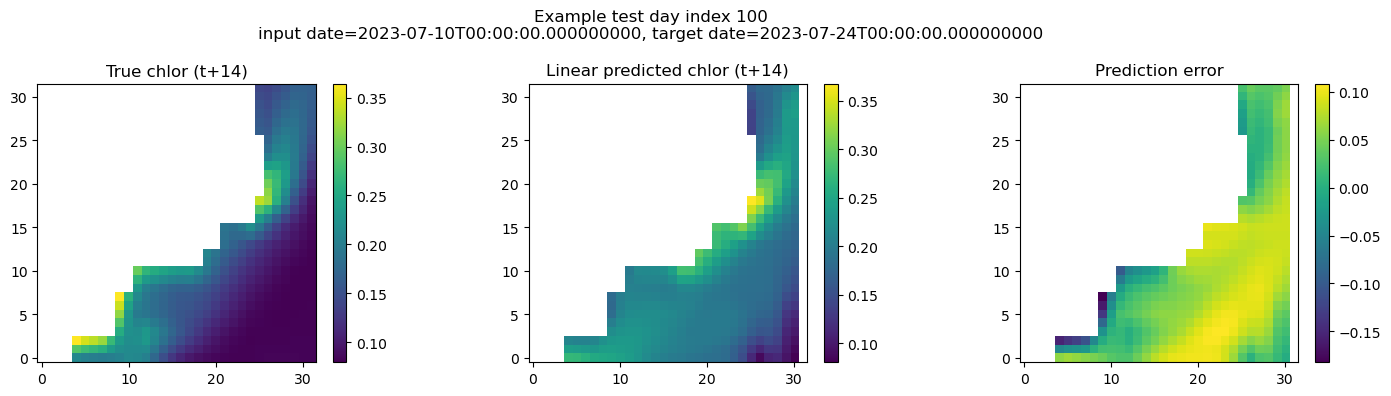

In [11]:
import matplotlib.pyplot as plt

test_idx = 100

X_sample = X_test[test_idx]
y_true_map = y_test[test_idx]

X_sample_flat = X_sample.reshape(-1, C)
mask_sample = np.all(np.isfinite(X_sample_flat), axis=1)

X_sample_scaled = scaler.transform(X_sample_flat[mask_sample])
y_pred_flat_valid = linreg.predict(X_sample_scaled)

y_pred_flat = np.full(X_sample_flat.shape[0], np.nan, dtype=float)
y_pred_flat[mask_sample] = y_pred_flat_valid

y_pred_map = y_pred_flat.reshape(H, W)

error_map = y_pred_map - y_true_map

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im0 = axes[0].imshow(y_true_map, origin="lower")
axes[0].set_title("True chlor (t+14)")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(y_pred_map, origin="lower")
axes[1].set_title("Linear predicted chlor (t+14)")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(error_map, origin="lower")
axes[2].set_title("Prediction error")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.suptitle(f"Example test day index {test_idx}\ninput date={str(time_test_input[test_idx])}, target date={str(time_test_target[test_idx])}")
plt.tight_layout()
plt.show()

/tmp/ipykernel_732/1456964147.py:21: RuntimeWarning: Mean of empty slice
  mean_bias = np.nanmean(error_maps, axis=0)
/tmp/ipykernel_732/1456964147.py:22: RuntimeWarning: Mean of empty slice
  rmse_map = np.sqrt(np.nanmean(error_maps**2, axis=0))


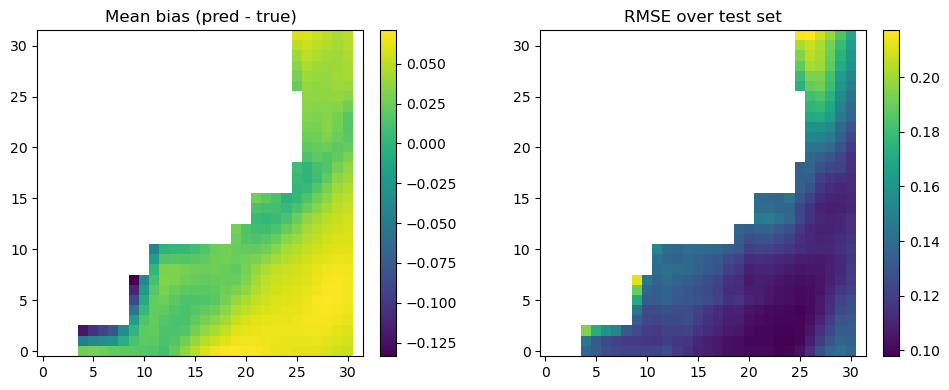

In [12]:
X_test_flat_all = X_test.reshape(-1, C)
y_test_flat_all = y_test.reshape(-1)

mask_all = np.isfinite(y_test_flat_all)
mask_all &= np.all(np.isfinite(X_test_flat_all), axis=1)

X_test_scaled_all = scaler.transform(X_test_flat_all[mask_all])
y_pred_flat_all_valid = linreg.predict(X_test_scaled_all)

y_pred_flat_all = np.full_like(y_test_flat_all, np.nan, dtype=float)
y_pred_flat_all[mask_all] = y_pred_flat_all_valid

y_true_all = y_test_flat_all
y_pred_all = y_pred_flat_all

y_true_maps = y_true_all.reshape(-1, H, W)
y_pred_maps = y_pred_all.reshape(-1, H, W)

error_maps = y_pred_maps - y_true_maps

mean_bias = np.nanmean(error_maps, axis=0)
rmse_map = np.sqrt(np.nanmean(error_maps**2, axis=0))

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].imshow(mean_bias, origin="lower")
axes[0].set_title("Mean bias (pred - true)")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(rmse_map, origin="lower")
axes[1].set_title("RMSE over test set")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

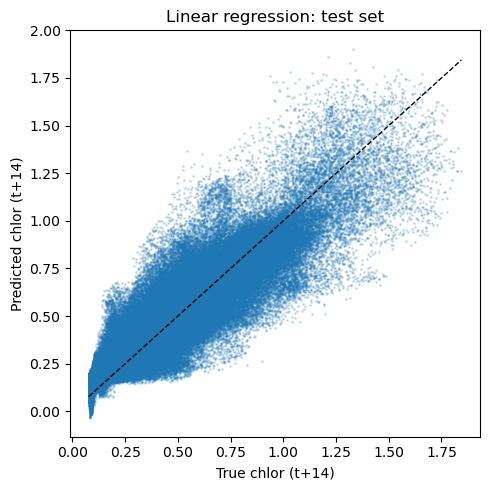

In [13]:
import matplotlib.pyplot as plt

mask_scatter = np.isfinite(y_true_all) & np.isfinite(y_pred_all)

y_true_scatter = y_true_all[mask_scatter]
y_pred_scatter = y_pred_all[mask_scatter]

plt.figure(figsize=(5, 5))
plt.scatter(y_true_scatter, y_pred_scatter, s=1, alpha=0.2)
min_val = np.nanmin(y_true_scatter)
max_val = np.nanmax(y_true_scatter)
plt.plot([min_val, max_val], [min_val, max_val], "k--", linewidth=1)
plt.xlabel("True chlor (t+14)")
plt.ylabel("Predicted chlor (t+14)")
plt.title("Linear regression: test set")
plt.tight_layout()
plt.show()

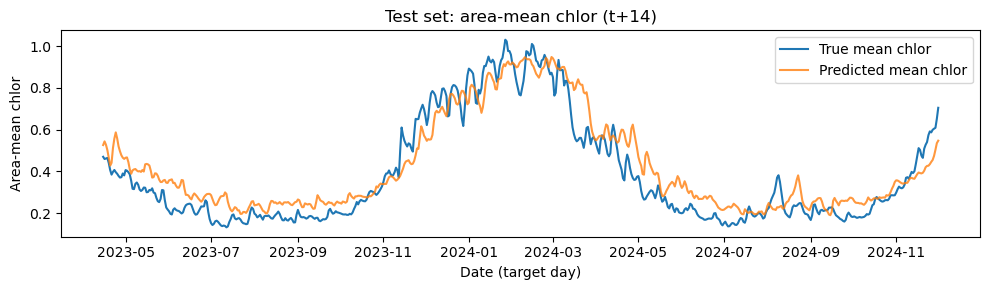

In [15]:
import numpy as np
import matplotlib.pyplot as plt

X_test_flat = X_test.reshape(-1, C)
y_test_flat = y_test.reshape(-1)
mask = np.isfinite(y_test_flat) & np.all(np.isfinite(X_test_flat), axis=1)

X_test_scaled = scaler.transform(X_test_flat[mask])
y_pred_flat = linreg.predict(X_test_scaled)

y_pred_maps = np.full_like(y_test, np.nan, dtype=float)

n_pixels = H * W
valid_idx = np.where(mask)[0]

for k, g in enumerate(valid_idx):
    t_idx = g // n_pixels
    p_idx = g % n_pixels
    i = p_idx // W
    j = p_idx % W
    y_pred_maps[t_idx, i, j] = y_pred_flat[k]

true_mean = np.nanmean(y_test, axis=(1, 2))
pred_mean = np.nanmean(y_pred_maps, axis=(1, 2))

plt.figure(figsize=(10, 3))
plt.plot(time_test_target, true_mean, label="True mean chlor")
plt.plot(time_test_target, pred_mean, label="Predicted mean chlor", alpha=0.8)
plt.xlabel("Date (target day)")
plt.ylabel("Area-mean chlor")
plt.title("Test set: area-mean chlor (t+14)")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

data = np.load("dataset_32_lag14_multi.npz", allow_pickle=True)

X = data["X"]
y = data["y"]
time_input = data["time_input"]
time_target = data["time_target"]
feature_names = data["feature_names"]

N, H, W, C = X.shape

N_train = int(N * 0.70)
N_val = int(N * 0.15)
N_test = N - N_train - N_val

X_train = X[:N_train]
y_train = y[:N_train]

X_val = X[N_train:N_train + N_val]
y_val = y[N_train:N_train + N_val]

X_test = X[N_train + N_val:]
y_test = y[N_train + N_val:]

time_train_input = time_input[:N_train]
time_train_target = time_target[:N_train]
time_val_input = time_input[N_train:N_train + N_val]
time_val_target = time_target[N_train:N_train + N_val]
time_test_input = time_input[N_train + N_val:]
time_test_target = time_target[N_train + N_val:]

X_train_flat = X_train.reshape(-1, C)
y_train_flat = y_train.reshape(-1)

X_val_flat = X_val.reshape(-1, C)
y_val_flat = y_val.reshape(-1)

X_test_flat = X_test.reshape(-1, C)
y_test_flat = y_test.reshape(-1)

def mask_valid(Xf, yf):
    mask = np.isfinite(yf)
    mask &= np.all(np.isfinite(Xf), axis=1)
    return Xf[mask], yf[mask]

X_train_f, y_train_f = mask_valid(X_train_flat, y_train_flat)
X_val_f, y_val_f = mask_valid(X_val_flat, y_val_flat)
X_test_f, y_test_f = mask_valid(X_test_flat, y_test_flat)

max_train_samples = 200000
if X_train_f.shape[0] > max_train_samples:
    idx_sub = np.random.choice(X_train_f.shape[0], size=max_train_samples, replace=False)
    X_train_sub = X_train_f[idx_sub]
    y_train_sub = y_train_f[idx_sub]
else:
    X_train_sub = X_train_f
    y_train_sub = y_train_f

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train_sub, y_train_sub)

for name, Xs, ys in [
    ("Train", X_train_f, y_train_f),
    ("Val", X_val_f, y_val_f),
    ("Test", X_test_f, y_test_f),
]:
    y_pred = rf.predict(Xs)
    mse = mean_squared_error(ys, y_pred)
    r2 = r2_score(ys, y_pred)
    print(f"{name} MSE: {mse:.4f}, R2: {r2:.4f}")

Train MSE: 0.0120, R2: 0.9048
Val MSE: 0.0252, R2: 0.7405
Test MSE: 0.0136, R2: 0.8413


/tmp/ipykernel_732/1824063914.py:18: RuntimeWarning: All-NaN axis encountered
  vmin = np.nanmin([y_true_map.min(), y_pred_map.min()])
/tmp/ipykernel_732/1824063914.py:19: RuntimeWarning: All-NaN axis encountered
  vmax = np.nanmax([y_true_map.max(), y_pred_map.max()])


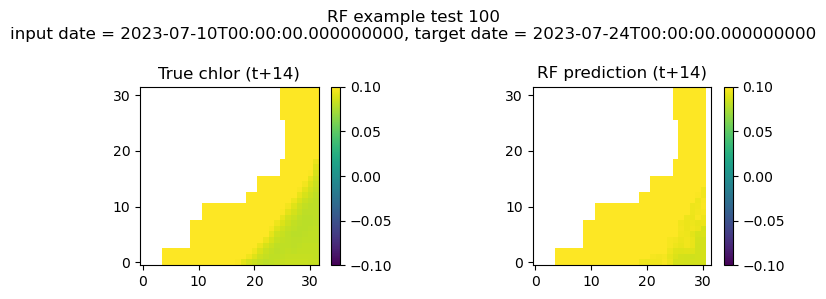

In [17]:
import matplotlib.pyplot as plt

test_idx = 100  # you can change this index

X_sample = X_test[test_idx]
y_true_map = y_test[test_idx]

X_sample_flat = X_sample.reshape(-1, C)
mask_sample = np.all(np.isfinite(X_sample_flat), axis=1)

y_pred_flat_valid = rf.predict(X_sample_flat[mask_sample])

y_pred_flat = np.full(X_sample_flat.shape[0], np.nan, dtype=float)
y_pred_flat[mask_sample] = y_pred_flat_valid

y_pred_map = y_pred_flat.reshape(H, W)

vmin = np.nanmin([y_true_map.min(), y_pred_map.min()])
vmax = np.nanmax([y_true_map.max(), y_pred_map.max()])

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

im0 = axes[0].imshow(y_true_map, origin="lower", vmin=vmin, vmax=vmax)
axes[0].set_title("True chlor (t+14)")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(y_pred_map, origin="lower", vmin=vmin, vmax=vmax)
axes[1].set_title("RF prediction (t+14)")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.suptitle(
    f"RF example test {test_idx}\n"
    f"input date = {str(time_test_input[test_idx])}, "
    f"target date = {str(time_test_target[test_idx])}"
)
plt.tight_layout()
plt.show()

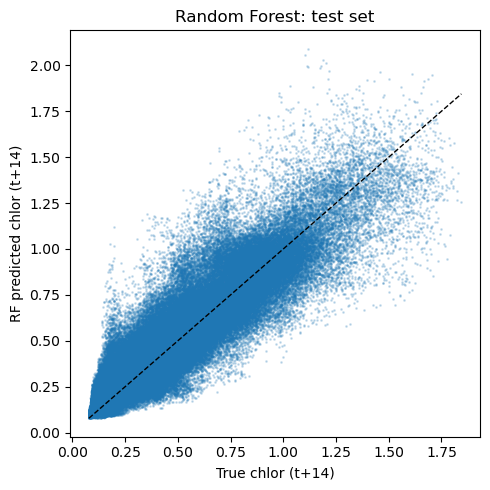

In [18]:
import matplotlib.pyplot as plt

X_test_f2, y_test_f2 = X_test_f, y_test_f

y_pred_rf = rf.predict(X_test_f2)

plt.figure(figsize=(5, 5))
plt.scatter(y_test_f2, y_pred_rf, s=1, alpha=0.2)

min_val = float(np.nanmin(y_test_f2))
max_val = float(np.nanmax(y_test_f2))
plt.plot([min_val, max_val], [min_val, max_val], "k--", linewidth=1)

plt.xlabel("True chlor (t+14)")
plt.ylabel("RF predicted chlor (t+14)")
plt.title("Random Forest: test set")
plt.tight_layout()
plt.show()

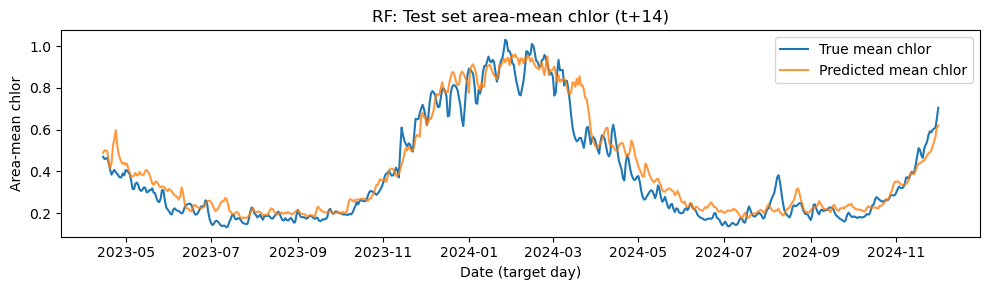

In [35]:
import numpy as np
import matplotlib.pyplot as plt

N_test, H, W, C = X_test.shape

y_test_flat_all = y_test.reshape(-1)
X_test_flat_all = X_test.reshape(-1, C)

mask_all = np.isfinite(y_test_flat_all)
mask_all &= np.all(np.isfinite(X_test_flat_all), axis=1)

X_test_valid = X_test_flat_all[mask_all]
y_pred_flat_valid = rf.predict(X_test_valid)

y_pred_flat_all = np.full_like(y_test_flat_all, np.nan, dtype=float)
y_pred_flat_all[mask_all] = y_pred_flat_valid

y_test_maps = y_test_flat_all.reshape(N_test, H, W)
y_pred_maps = y_pred_flat_all.reshape(N_test, H, W)

true_mean = np.nanmean(y_test_maps, axis=(1, 2))
pred_mean = np.nanmean(y_pred_maps, axis=(1, 2))

time_test_target = time_target[N_train+N_val : N_train+N_val+N_test]

plt.figure(figsize=(10, 3))
plt.plot(time_test_target, true_mean, label="True mean chlor")
plt.plot(time_test_target, pred_mean, label="Predicted mean chlor", alpha=0.8)
plt.xlabel("Date (target day)")
plt.ylabel("Area-mean chlor")
plt.title("RF: Test set area-mean chlor (t+14)")
plt.legend()
plt.tight_layout()
plt.show()